# **Modelagem de Tópicos**
<font size=3>

As tarefas **não-supervisionadas** de Aprendizado de Máquina têm desempenhado um papel fundamental no avanço do Processamento de Linguagem Natural (PLN), especialmente em contextos onde há **escassez de dados rotulados**. Ao contrário das abordagens supervisionadas, que dependem de grandes volumes de exemplos anotados manualmente, **os métodos não-supervisionados exploram padrões e estruturas ocultas** diretamente em dados brutos.

Em PLN, essas técnicas são amplamente aplicadas em tarefas como **modelagem de tópicos**, **agrupamento de documentos**, **detecção de anomalias linguísticas** e **aprendizagem de representações semânticas** (como vetores de palavras).

> Observe que parte destas abordagens já foi estudada na aula de **Análise Semântica**, mas agora, podemos compreendê-las como abordagens não-supervisionadas.

## **1. Modelagem de Tópicos**:
<font size=3>

A **modelagem de tópicos** é uma técnica de **aprendizado não-supervisionado** utilizada para **descobrir os temas ocultos (tópicos latentes)** presentes em um grande conjunto de documentos de texto.

<font size=3>

Esses **tópicos são conjuntos de palavras que frequentemente aparecem juntas** em diferentes contextos, e cada documento pode tratar de múltiplos tópicos em diferentes proporções.

Por exemplo, em um conjunto de artigos de notícias, podemos encontrar tópicos como *política*, *esportes*, *tecnologia*, *saúde*, etc., mesmo que esses temas não estejam explicitamente rotulados. Assim, à medida que o volume de dados textuais cresce (artigos, redes sociais, reviews, etc.), torna-se impraticável processar manualmente todas as informações. A modelagem de tópicos permite:
* **Explorar grandes volumes de texto** de forma automatizada;
* **Resumir coleções de documentos** com base nos temas principais;
* **Agrupar documentos semelhantes** por conteúdo;
* **Ajudar em tarefas _downstream_**, como recomendação de conteúdo, recuperação de informação, classificação e análise de sentimento.

### **1.1 Como funciona a modelagem de tópicos:**
<font size=3>

A ideia central é **representar documentos como distribuições de tópicos**, e tópicos como distribuições de palavras, ou seja:
 * Cada **documento** é uma mistura de vários tópicos (com diferentes pesos);
 * Cada **tópico** é um conjunto de palavras com uma certa probabilidade de ocorrência.
 <br>

Por exemplo:
 * Documento: "A seleção brasileira venceu o jogo por 3 a 0";
 * Tópico provável: *Esportes*;
 * Palavras associadas ao tópico: ["jogo", "goleiro", "seleção", "campeonato", "vitória"].

### **1.2 Técnicas comuns de modelagem de tópicos:**
<font size=3>

Existem diferentes métodos para modelar tópicos, incluindo:
* **Latent Semantic Analysis (LSA)**: baseado em álgebra linear (SVD).
* **[Non-negative Matrix Factorization](https://en.wikipedia.org/wiki/Non-negative_matrix_factorization) (NMF)**: fatoração de matrizes com restrições de não negatividade (abordagem semelhante à Decomposição de Valores Singulares).
* **Latent Dirichlet Allocation (LDA)**: abordagem probabilística que modela tópicos como variáveis latentes.

<br>

A seguir, vamos explorar em detalhes o modelo **Latent Dirichlet Allocation (LDA)**, que é uma das abordagens mais populares e poderosas para modelagem de tópicos.

## **2. O modelo LDA:**
<font size=3>
    
O **Alocação Latente de Dirichlet** (*Latent Dirichlet Allocation* — LDA) é um algoritmo probabilístico fundamental para a modelagem de tópicos.

<font size=3>

A premissa central do LDA é que os documentos são gerados a partir de uma mistura de temas latentes (ocultos). Para isso, o modelo se baseia em duas suposições principais:

1.  **Documentos como Mistura de Tópicos:** Cada documento é visto como uma combinação de múltiplos tópicos, em diferentes proporções. Por exemplo, ao analisar uma coleção de notícia, um artigo específico pode ser 70% "Política" e 30% "Economia".

2.  **Tópicos como Mistura de Palavras:** Cada tópico é, por sua vez, uma distribuição de probabilidades sobre o vocabulário. Por exemplo, o tópico "Esportes" é definido por altas probabilidades em palavras como "bola", "jogo" e "time".

> **O objetivo do LDA** é, portanto, analisar o texto bruto e *descobrir* automaticamente essas duas estruturas: *__quais são as distribuições de palavras que formam os tópicos__ e __quais são as proporções de tópicos em cada documento__*, tudo isso sem que precisemos informar ao modelo quais são os tópicos de antemão.

### **2.1 O Processo Generativo:**
<font size=3>
    
O LDA é um **modelo generativo probabilístico**. Isso significa que ele opera com base em uma "história" (ou "receita") que descreve, passo a passo, como um conjunto de documentos é *estatisticamente gerado*.

Vamos imaginar essa receita para uma coleção de $D$ documentos, $K$ tópicos e um vocabulário de $V$ palavras.

> Do ponto de vista da Álgebra Linear, o LDA funciona como um método de **fatorização de matrizes**. Ele tenta decompor a matriz original de entrada $M$ (Documento-Termo) no produto destas duas matrizes de probabilidade mais pequenas: a matriz **tópico-palavra** ($\beta_{K\times V}$) e a matriz **documento-tópico** ($\theta_{D\times K}$), tal que
>$$M = \theta\cdot \beta$$
>

<font size=3>
    
**Etapa 1 — A Geração dos Tópicos:**

Antes de qualquer documento ser escrito, o modelo define os $K$ tópicos que existem no "universo" da coleção.

* **O que é um tópico?** Um tópico $k$ é definido por uma distribuição de probabilidades sobre *todo* o vocabulário, que chamamos de $\beta_k$.

* **Exemplo:** $\beta_k$ é um vetor que diz: $P(\text{``carro''} \mid \text{Tópico}\, k) = 0.5,\, P(\text{``motor''} \mid \text{Tópico}\, k) = 0.3,\, \dots,\, P(\text{ ``espaço''} \mid \text{Tópico}\, k) = 0.01$.

* **A Fórmula:** Para gerar esse vetor de probabilidades $\beta_k$, o modelo o amostra de uma [Distribuição de Dirichlet](https://en.wikipedia.org/wiki/Dirichlet_distribution):
    $$\beta_k \sim \text{Dir}(\eta)$$

* **Por que Dirichlet?** A distribuição de Dirichlet é usada porque ela gera vetores de números que somam 1 — exatamente o que precisamos para uma distribuição de probabilidade.

* **Hiperparâmetro $\eta\,$:** Controla a *dispersão* das palavras no tópico. Um $\eta$ baixo cria tópicos "esparsos" (dominados por poucas palavras-chave), enquanto um $\eta$ alto cria tópicos "densos" (mais genéricos).

Isso é feito para todos os $K$ tópicos, criando a "paleta" de temas $\beta = \{\beta_1, ..., \beta_K\}$.

<font size=3>

**Etapa 2 — A Geração do Documento:**

Agora, para *cada* documento $d$ que será escrito (de $d=1$ até $D$):

* **O que é um documento?** O documento $d$ é definido por sua própria mistura de tópicos, que chamamos de $\theta_d$.

* **Exemplo:** $\theta_d$ é um vetor que diz: $P(\text{Tópico 1} \mid \text{Doc}\, d) = 0.7,\, P(\text{Tópico 2} \mid \text{Doc}\, d) = 0.3\quad$ (Este documento é 70% sobre Tópico 1 e 30% sobre Tópico 2).

* **A Fórmula:** Para gerar essa mistura $\theta_d$, o modelo novamente usa uma **Distribuição de Dirichlet**:
    $$\theta_d \sim \text{Dir}(\alpha)$$

* **Hiperparâmetro $\alpha\,$:** Controla a *mistura* de tópicos no documento. Um $\alpha$ baixo gera documentos "puros" (focados em poucos tópicos), enquanto um $\alpha$ alto gera documentos que são uma "sopa" uniforme de *muitos* tópicos.

<font size=3>
    
**Etapa 3 — A Geração das Palavras:**

Finalmente, para gerar *cada palavra* $w$ na posição $n$ do documento $d$:

1.  **Escolher um Tópico ($z_{dn}$):**
    * Primeiro, o modelo olha para a mistura de tópicos do documento ($\theta_d$) e "sorteia" um tópico $z_{dn}$ para esta palavra específica.
        
        $$
            z_{dn} \sim \text{Multinomial}(\theta_d)
        $$

    >Estamos escolhendo *uma* categoria (um tópico) de $K$ opções, e as probabilidades de cada escolha são dadas por $\theta_d$.

    <br>
    
2.  **Escolher uma Palavra ($w_{dn}$):**
    * Uma vez que o tópico (digamos, o Tópico $k=z_{dn}$) foi escolhido, o modelo agora usa a distribuição de palavras *desse tópico* ($\beta_k$) para sortear a palavra final.
        
        $$
            w_{dn} \sim \text{Multinomial}(\beta_{z_{dn}})
        $$

    >Estamos escolhendo *uma* palavra do vocabulário de $V$ opções, e as probabilidades de cada escolha são dadas por $\beta_{z_{dn}}$.

Este processo de duas etapas (Escolher Tópico $\rightarrow$ Escolher Palavra) é repetido para todas as $N_d$ palavras do documento.

### **2.2 O Problema da Inferência:**
<font size=3>
    
A história acima é o *processo generativo*. Na prática, nós **não temos** as variáveis latentes (ocultas):

* Não sabemos as distribuições de palavras dos tópicos ($\beta_k$).
* Não sabemos as misturas de tópicos dos documentos ($\theta_d$).
* Não sabemos a qual tópico cada palavra foi atribuída ($z_{dn}$).

Nós temos **apenas** os dados observados: as palavras $\mathbf{w}$ em todos os documentos.

O objetivo do algoritmo LDA é fazer a **inferência**: calcular a probabilidade *posterior* de todas essas variáveis ocultas, dados os documentos que observamos. Matematicamente, queremos encontrar a distribuição *a priori*
$$
    P(\beta, \theta, \mathbf{z} \mid \mathbf{w}, \alpha, \eta) = \frac{P(\mathbf{w}, \mathbf{z}, \theta, \beta \mid \alpha, \eta)}{P(\mathbf{w} \mid \alpha, \eta)} \, .
$$
> *Dado o texto real observável $\mathbf{w}$ e os hiperparâmetros $\alpha, \eta$, qual é a probabilidade dos tópicos $\beta$, das misturas $\theta$ e das atribuições de palavras $\mathbf{z}$ assumirem determinados valores?*

Para fazer isso, o modelo parte da **probabilidade conjunta**, que é a multiplicação de todas as etapas da receita:

$$
P(\mathbf{w}, \mathbf{z}, \theta, \beta \mid \alpha, \eta) =
\prod_{k=1}^K \underbrace{P(\beta_k \mid \eta)}_{\text{Etapa 1}} \times
\prod_{d=1}^D \left( \underbrace{P(\theta_d \mid \alpha)}_{\text{Etapa 2}}
\prod_{n=1}^{N_d} \underbrace{P(z_{dn} \mid \theta_d) P(w_{dn} \mid \beta_{z_{dn}})}_{\text{Etapa 3}} \right)
$$

> Algoritmos como *Amostragem de Gibbs* ou *Inferência Variacional* (usado no `sklearn`) são os métodos computacionais usados para "resolver" essa equação e encontrar os valores mais prováveis para $\beta$, $\theta$ e $\mathbf{z}$ que melhor explicam os dados $\mathbf{w}$ que temos.

<font size=3>

> **Observações:**
>* LDA, em sua formulação teórica original (como descrito na aula), é um modelo generativo baseado em **contagens** de palavras (Bag-of-Words), não em pesos TF-IDF. O processo descreve a *escolha* de uma palavra, o que implica contagens discretas.
>* Portanto, o `CountVectorizer` do Scikit-Learn é a entrada mais "pura" e teoricamente correta para o LDA.
>* Podemos explicar que, embora o `TfidfVectorizer` possa ser usado (e às vezes ajuda a "silenciar" palavras muito comuns que não são *stopwords*), é conceitualmente diferente.


In [1]:
import re
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [2]:
# carregando um conjunto de documentos:
newsgroups = fetch_20newsgroups(subset='all', categories=['sci.space', 'rec.autos'],
                                remove=('headers', 'footers', 'quotes'))
docs = newsgroups.data

In [3]:
# vetorização dos documentos:
def Preprocessor(text):

    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\_+", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r'\s+', ' ', text)

    return text

vec = CountVectorizer(preprocessor=Preprocessor, stop_words="english", min_df=10, max_df=0.9)

X = vec.fit_transform(docs)

vocab = vec.get_feature_names_out()

print("Tamanho do vocabulário:", len(vocab))
vocab[:10], vocab[-10:]

Tamanho do vocabulário: 2271


(array(['ability', 'able', 'abs', 'absolutely', 'ac', 'acceleration',
        'acceptable', 'accepted', 'access', 'accident'], dtype=object),
 array(['years', 'yes', 'yesterday', 'york', 'youd', 'youll', 'young',
        'youre', 'youve', 'zero'], dtype=object))

In [4]:
# parâmetros:
η = None # dafault: 1/n_topics
α = None # dafault: 1/n_topics

n_topics = 2
n_top_words = 10

# treinando o modelo LDA:
model = LatentDirichletAllocation(n_components=n_topics, doc_topic_prior=α, topic_word_prior=η)
model.fit(X)

LatentDirichletAllocation(n_components=2)

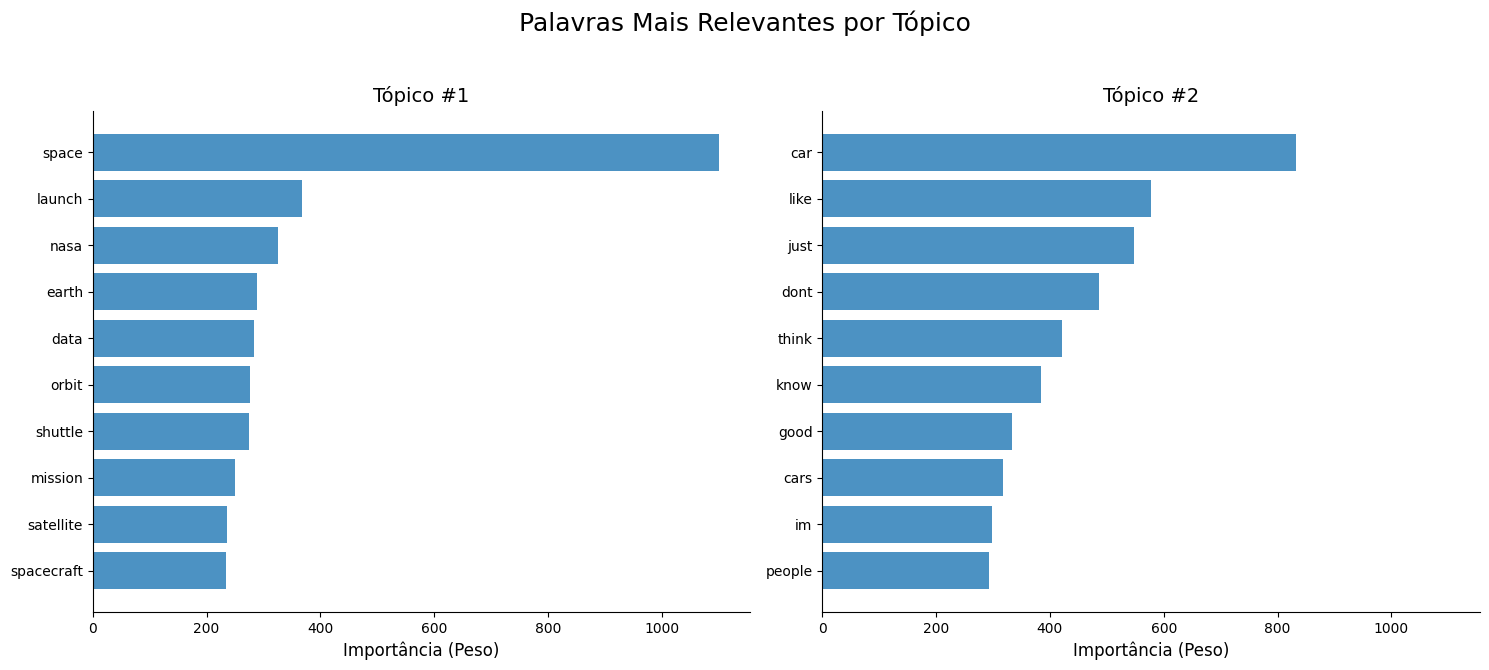

In [5]:
# visualizando os tópicos:
fig, axes = plt.subplots(1, n_topics, figsize=(15, 7), sharex=True)

fig.suptitle("Palavras Mais Relevantes por Tópico", fontsize=18)

if n_topics == 1:
    axes = [axes]

axes = axes.flatten()

β = model.components_

for topic_idx, topic in enumerate(β):
    top_tokens_index = topic.argsort()[:-n_top_words-1:-1]

    top_tokens = [vocab[i] for i in top_tokens_index]
    weights = topic[top_tokens_index]

    top_tokens = top_tokens[::-1]
    weights = weights[::-1]

    ax = axes[topic_idx]
    ax.barh(top_tokens, weights, color='tab:blue', alpha=0.8)
    ax.set_title(f'Tópico #{topic_idx + 1}', fontsize=14)
    ax.set_xlabel('Importância (Peso)', fontsize=12)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

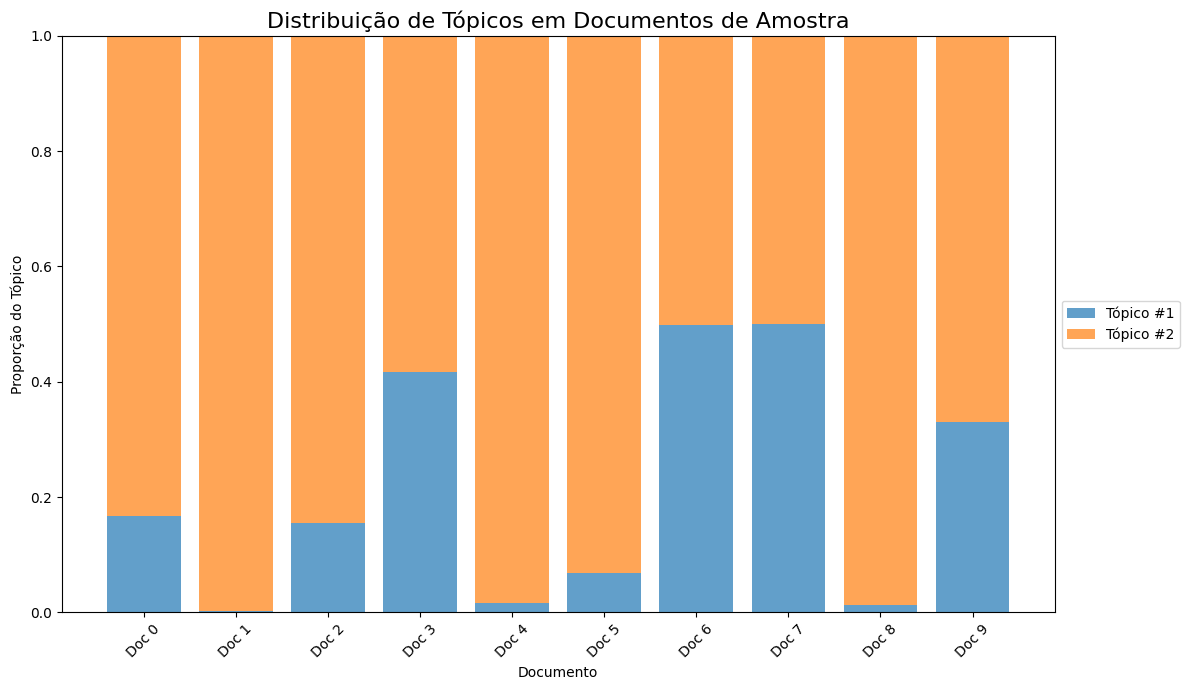

In [6]:
# obtendo a distribuição de tópicos para cada documento:
θ = model.transform(X)

# visualizar os 10 primeiros documentos:
n_docs = 10
θ_sample = θ[:n_docs]

# preparando os dados para o gráfico de barras empilhadas:
n_topics = model.n_components
doc_labels = [f"Doc {i}" for i in range(n_docs)]
colors = ['tab:blue', 'tab:orange']

plt.figure(figsize=(12, 7))
plt.title('Distribuição de Tópicos em Documentos de Amostra', fontsize=16)

bottom = np.zeros(n_docs)

for topic_idx in range(n_topics):
    proportions = θ_sample[:, topic_idx]

    plt.bar(doc_labels, proportions, bottom=bottom, label=f'Tópico #{topic_idx + 1}',
            color=colors[topic_idx % len(colors)], alpha=0.7)

    bottom += proportions

plt.ylim(0, 1)
plt.xlabel('Documento')
plt.ylabel('Proporção do Tópico')
plt.xticks(rotation=45)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

<font size=3>
<br>
    
O modelo LDA é bastante vantajoso por ser capaz de **analisar grandes volumes de texto** de forma *não-supervisionada*, **extraindo temas latentes de maneira interpretável**, ou seja, associando tópicos a conjuntos de palavras relevantes. Além disso, ele **permite que um mesmo documento pertença a múltiplos tópicos**, refletindo melhor a complexidade dos textos reais.

Por outro lado, o LDA possui limitações importantes. Suas suposições simplificadas, como a **independência entre tópicos** e o uso do **modelo de "saco de palavras" (BoW)**, podem limitar a qualidade dos resultados. **A coerência dos tópicos gerados depende fortemente do ajuste cuidadoso de hiperparâmetros**, e **o número de tópicos ($K$) deve ser definido manualmente**. Além disso, o modelo tende a ter **desempenho inferior com textos curtos**, como postagens em redes sociais. Isso ocorre porque o LDA baseia-se na coocorrência de palavras dentro de um mesmo documento para inferir os tópicos. Em textos muito curtos, há pouca informação contextual (poucas palavras por documento), dificultando a convergência estatística da distribuição $\theta_d$.

## __Referências:__
<font size=3>

 - **(4.5)**: [Natural Language Processing in Action](https://www.manning.com/books/natural-language-processing-in-action).
